## __Cơ sở lý thuyết__

### __BERT__

Mô hình __BERT__ (**B**idirectional **E**ncoder **R**epresentations from **T**ransformers) là một mô hình máy học (**M**achine **L**earning - **ML**) mã nguồn mở được các nhà nghiên cứu tại Google phát triển để giải quyết nhiều bài toán xử lý ngôn ngữ tự nhiên (**N**atural **L**anguage **P**rocessing - **NLP**) và lần đầu được giới thiệu vào năm 2018 trong __[bài báo này](https://arxiv.org/abs/1810.04805)__.
> _Fun fact_: Dù không nhận ra nhưng thực ra ta tương tác với BERT hằng ngày đấy! Mỗi lần ta search trên Google thì chính mô hình này đã tham gia hỗ trợ trong việc hiểu bạn đang tìm kiếm gì để trả về kết quả tốt nhất. (__[source](https://searchengineland.com/google-bert-used-on-almost-every-english-query-342193)__)

Một số điểm đáng chú ý của mô hình này:
- BERT được huấn luyện trên Masked Language Model (MLM). Điều này có nghĩa là mô hình học bằng cách che lại một số từ trong câu và phải đoán từ đó bằng cách học hai chiều (Bidirectional) các từ còn lại của câu. Phương pháp này khá tương đồng với cách con người ta sử dụng ngôn ngữ.
> Trong quá trình học ngôn ngữ, không quan trọng ở quốc gia nào, học sinh cũng phải làm các bài tập điền vào chỗ trống để hoàn thành câu. Đây chính là ý tưởng đằng sau quá trình phát triển mô hình này. Bạn có thể điền vào chỗ trống từ còn thiếu trong câu sau không? <br>
> __"Em ... cơm chưa?"__ <br>
> Mô hình BERT, tương tự như cách bạn giải bài tập trên, cũng học bằng cách giải các bài tập như vậy. Trong quá trình training, xấp xỉ 15% số lượng từ trong câu sẽ bị ẩn đi và nhiệm vụ của BERT là đoán từ đó. Có lẽ trí tuệ nhân tạo và trí tuệ con người không thực sự khác biệt là bao.

- BERT cũng được huấn luyện trên Next Sentence Prediction (NSP). Điều đó giúp BERT học về mối quan hệ giữa các câu với nhau bằng cách dự đoán liệu một câu có phải là câu kế tiếp cho một câu khác. Công việc này được thực hiện song song với MLM nói trên với tỉ lệ xấp xỉ 1:1.
> Ví dụ: <br>
> __"Em ... cơm chưa?" - "Em ăn ... ạ."__ (đúng) <br>
> __"Em ... cơm chưa?" - "Chiều nay ai ra xứ ...."__ (sai)

- Về mặt bản chất, BERT thực chất chỉ là rất nhiều lớp Transformer Encoders đã được huấn luyện được nối với nhau. Mô hình Transformer hỗ trợ cho việc hiểu được mối quan hệ về mặt bối cảnh giữa các từ với nhau bằng cách đọc toàn bộ các chuỗi từ trong câu (ví dụ hiểu được _"cô ấy"_ là nhắc đến ai). Bằng cách sử dụng cơ chế tập trung (Attention), một thuật toán học sâu (Deep Learning) mạnh mẽ, mô hình có tính song song hóa (Parallelization) cao, sử dụng ít tài nguyên và dễ dàng học chuyển tiếp (Transfer Learning) để giải quyết các bài toán khác nhau.

## __Triển khai dự án__

### __Chuẩn bị__

#### _Cài đặt các thư viện cần thiết_

In [1]:
pip install -q numpy matplotlib seaborn datasets evaluate transformers[torch] matplotlib seaborn watermark scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.5 MB/s eta 0:00:00


#### _Kiểm tra phiên bản của các thư viện_

#### _Khai báo các phụ thuộc của chương trình_

In [2]:
from datasets import load_dataset
import numpy as np
import evaluate
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import transformers
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

#### _Kiểm tra thiết bị có hỗ trợ cuda_

#### _Khởi tạo các dữ liệu cần thiết_

Khởi tạo seed random để dễ dàng thực hiện lại với kết quả giống nhau:

In [3]:
RANDOM_SEED = 36
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
transformers.set_seed(RANDOM_SEED)

Khởi tạo matplotlib và seaborn để đồng nhất thiết kế biểu đồ:

In [4]:
%matplotlib inline
sns.set(style='whitegrid', palette='pastel', font_scale=1.2)

### __Nghiên cứu dữ liệu__

#### _Tải dataset và đưa vào bộ nhớ_

Muốn xử lí dữ liệu trước hết ta phải có dữ liệu. May mắn thay, rất nhiều thư viện python được sinh ra để giúp cho việc này ngày càng đơn giản. Với thư viện Transformers của Hugging Face, việc tải và đưa dataset (đã được đăng trên Hugging Face) vào bộ nhớ chỉ cần đúng 1 dòng lệnh sau:

In [5]:

dataset = load_dataset("tridm/UIT-VSMEC")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5548 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/693 [00:00<?, ? examples/s]

#### _Kiểm tra nội dung của dataset_

Ta sẽ chuyển định dạng của dataset sang _pandas_ để thuận tiện cho việc nhanh chóng xem và vẽ biểu đồ cho dữ liệu:

In [6]:
# Chuyển tập train sang pandas
df = dataset['train'].to_pandas()

Xem sơ qua dữ liệu:

In [7]:
df

,Sentence,Emotion
0,cho mình xin bài nhạc tên là gì với ạ,Other
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment
...,...,...
5543,đường của nhà cụ hay sao mà cụ cấm người ta đỗ...,Disgust
5544,nhìn mặt héo queo luôn,Other
5545,tao đi xe máy mỗi lần muốn để xe đi đâu là phi...,Other
5546,thích thân hình boss rồi nhan 😌,Enjoyment


Ở đây dataset đã được chia thành các split sẵn để thuận tiện cho việc sử dụng. Ta sẽ sử dụng split _train_ để huấn luyện, split _validation_ để kiểm tra hiệu suất trong quá trình huấn luyện, và split _test_ để thực hiện kiểm tra sau cuối cùng sau huấn luyện để đánh giá mô hình.

Ta sẽ định nghĩa các dictionary để dễ dàng chuyển đổi giữa dữ liệu và ý nghĩa để hiển thị cụ thể hơn các cảm nghĩ cũng như chủ đề của bài đánh giá:

Kiểm tra độ cân bằng của dữ liệu:

In [8]:
# Danh sách nhãn cảm xúc từ dataset UIT-VSMEC
# Cập nhật dựa trên dữ liệu thực tế trong cột 'Emotion' sau khi tải dataset
emotion_labels = [
    "Other", "Disgust", "Enjoyment", "Sadness", "Fear", "Surprise", "Anger"
]

# Tạo các từ điển ánh xạ (sẽ cần sau này khi chuyển đổi nhãn)
# Lưu ý: VSMEC là dataset multi-label, nhưng dữ liệu train ban đầu có vẻ là single-label
# Ta sẽ tạo ánh xạ cho các nhãn này trước
emotion_id2label = {i:l for i,l in enumerate(emotion_labels)}
emotion_label2id = {l:i for i,l in enumerate(emotion_labels)}

num_labels = len(emotion_labels) # Sẽ là 7
print(f"Defined {num_labels} emotion labels: {emotion_labels}")

Defined 7 emotion labels: ['Other', 'Disgust', 'Enjoyment', 'Sadness', 'Fear', 'Surprise', 'Anger']


Emotion
Enjoyment    1558
Disgust      1071
Other        1021
Sadness       947
Anger         391
Fear          318
Surprise      242
Name: count, dtype: int64


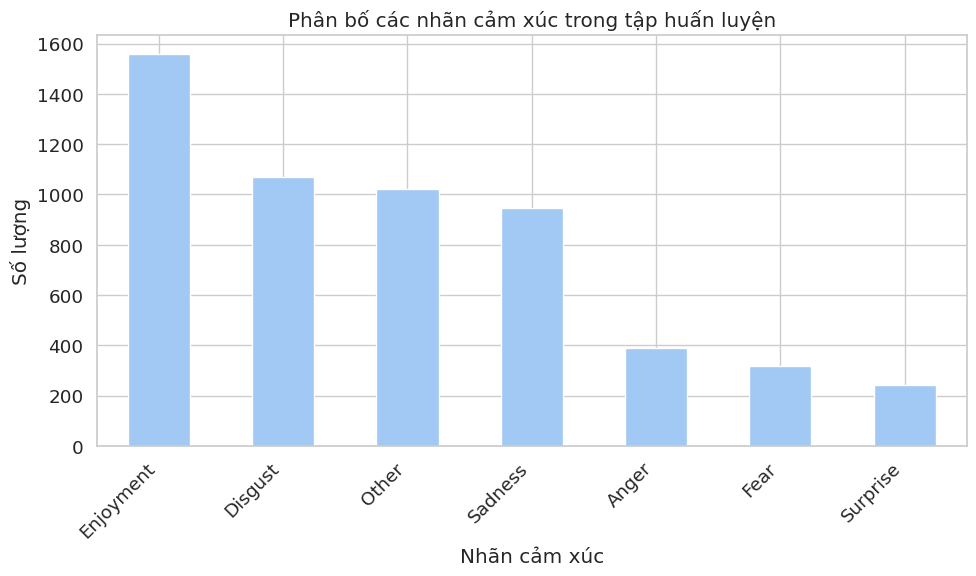

In [9]:
# Tính tổng số lần xuất hiện của mỗi cảm xúc bằng cách đếm giá trị trong cột 'Emotion'
emotion_counts = df['Emotion'].value_counts()

# In kết quả và vẽ biểu đồ
print(emotion_counts)

plt.figure(figsize=(10, 6)) # Tăng kích thước biểu đồ cho dễ nhìn
emotion_counts.plot(kind='bar')
plt.title('Phân bố các nhãn cảm xúc trong tập huấn luyện') # Thêm tiêu đề
plt.xlabel('Nhãn cảm xúc') # Thêm nhãn trục x
plt.ylabel('Số lượng') # Thêm nhãn trục y
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục x cho dễ đọc
plt.tight_layout() # Tự động điều chỉnh khoảng cách
plt.show() # Hiển thị biểu đồ

### __Xử lí dữ liệu__

Nếu đã từng làm việc với máy học thi ta biết rằng các mô hình không hoạt động trên dữ liệu văn bản thuần. Ta cần phải chế biến dữ liệu văn bản này thành một dạng nào đó thì các mô hình này mới có thể làm việc và học được. Mô hình BERT yêu cầu dữ liệu phải thỏa mãn các yêu cầu sau:
- Có các token đặc biệt để ngăn cách các câu và để thực hiện nhận dạng.
- Các chuỗi câu phải có cùng kích thước với nhau. Nếu dữ liệu dài hay ngắn hơn thì phải thực hiện đệm thêm (padding) hoặc bỏ bớt (truncating) đi ký tự để cho có cùng một kích thước.
- Phải có một mảng _attention_masks_ gồm các giá trị 1 và 0 để đánh dấu các token cần quan tâm và token bị bỏ qua.

Thư viện Transformers rất tiện lợi cung cấp cho chúng ta các Tokenizer đã được huấn luyện sẵn dùng để token hóa dữ liệu để trở thành dạng phù hợp cho các mô hình, bao gồm cả BERT. Hơn nữa, ta có thể sử dụng lớp hỗ trợ AutoTokenizer để thư viện chọn Tokenizer hợp lý nhất cho mô hình của mình. Ta sẽ nghiên cứu cách hoạt động của nó.

In [10]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 5548
    })
    validation: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 686
    })
    test: Dataset({
        features: ['Sentence', 'Emotion'],
        num_rows: 693
    })
})

Cài & khởi tạo VnCoreNLP (RDRSegmenter)

In [11]:
!pip install -q vncorenlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 33.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [12]:
!apt-get -qq install openjdk-8-jdk-headless -y > /dev/null

In [13]:
# 3. Tải bộ cài VnCoreNLP (file .zip)
!wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip



--2025-12-22 08:33:16--  https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master [following]
--2025-12-22 08:33:16--  https://codeload.github.com/vncorenlp/VnCoreNLP/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.116.9
Connecting to codeload.github.com (codeload.github.com)|140.82.116.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [             <=>    ] 160.84M  27.1MB/s    in 7.2s    

2025-12-22 08:33:23 (22.4 MB/s) - ‘master.zip’ saved [168648997]



In [14]:
# 4. Giải nén file zip
!unzip -q master.zip

In [15]:
from vncorenlp import VnCoreNLP

# 5. Khởi tạo VnCoreNLP với đường dẫn mới
# Trỏ vào /content/VnCoreNLP-master/VnCoreNLP-1.1.1.jar.. nếu dùng colab và
# /kaggle/working/VnCoreNLP-master/VnCoreNLP-1.1.1.jar nếu dùng kaggle

vncorenlp_path = "/content/VnCoreNLP-master/VnCoreNLP-1.1.1.jar"

# Khởi tạo (sử dụng annotator 'wseg' để tách từ giống như bạn)
rdr = VnCoreNLP(vncorenlp_path, annotators="wseg", max_heap_size='-Xmx2g')

print(" VnCoreNLP loaded successfully!")

# 6. Sử dụng để tách từ
text = "Phim này chán ngắt, phí cả tiền vé 😡 "

segmented_text = rdr.tokenize(text)
print(segmented_text)

 VnCoreNLP loaded successfully!
[['Phim', 'này', 'chán_ngắt', ',', 'phí', 'cả', 'tiền', 'vé', '😡']]


Hàm tách từ + batching + cache

In [16]:

from typing import List, Optional
import hashlib
import pickle
import os

CACHE_DIR = "/content/seg_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, name)

def segment_vi(text: str) -> str:
    """Tách từ 1 câu: trả về chuỗi có các từ cách nhau bởi khoảng trắng, đa âm nối '_'."""
    if not isinstance(text, str):
        text = "" if text is None else str(text)
    # rdr.tokenize trả về List[List[str]] (mỗi sent 1 list token). Ghép lại theo space.
    sents = rdr.tokenize(text)
    # Flatten các câu -> 1 list token, rồi join bằng space
    tokens = []
    for sent in sents:
        tokens.extend(sent)
    return " ".join(tokens)

def batch_segment(texts: List[str], cache_name: Optional[str]=None, batch_size: int=256) -> List[str]:
    """Tách từ theo batch; có cache để lần sau không phải làm lại."""
    if cache_name is None:
        # tạo tên cache ổn định theo hash nội dung (nhanh với số lượng vừa phải)
        m = hashlib.md5(("||".join(map(lambda x: x if isinstance(x, str) else str(x), texts))).encode("utf-8")).hexdigest()
        cache_name = f"seg_{m}.pkl"
    path = _cache_path(cache_name)
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    out = []
    for i in range(0, len(texts), batch_size):
        chunk = texts[i:i+batch_size]
        # rdr.tokenize có thể nhận list(str) và trả về list(list(list(str)))
        para_tok = rdr.tokenize(chunk)
        # Ghép mỗi đoạn văn thành 1 dòng tách từ
        for sents in para_tok:
            tokens=[]
            for sent in sents:
                tokens.extend(sent)
            out.append(" ".join(tokens))
    with open(path, "wb") as f:
        pickle.dump(out, f)
    return out

Tải Tokenizer và đưa vào bộ nhớ.

In [17]:


# 1. Từ điển Mapping Icon
icon_mapping = [
    ("😡", "giận"), ("😠", "giận"), ("🤬", "chửi"),
    ("😭", "khóc"), ("😢", "buồn"), ("☹️", "buồn"),
    ("😁", "cười"), ("😂", "cười"), ("🤣", "cười"),
    ("😱", "sợ"), ("😨", "sợ"),
    ("🥰", "yêu"), ("❤️", "yêu"),
    ("👍", "tốt"), ("🥹", "khóc")
]

In [18]:
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset, DatasetDict
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from sklearn.metrics import f1_score
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

# === Your labels/setup ===
# Update labels based on the actual data observed in the notebook
emotion_labels = [
    "Other", "Disgust", "Enjoyment", "Sadness", "Fear", "Surprise", "Anger"
]
NUM_LABELS = len(emotion_labels) # Should be77

id2label = {i: l for i, l in enumerate(emotion_labels)}
label2id = {l: i for i, l in enumerate(emotion_labels)}



# --- CẤU HÌNH ---
MODEL_NAME = "vinai/phobert-base-v2"

# 1. Load Config & Tokenizer
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="single_label_classification"
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)



# A. Lấy danh sách icon cần thêm
new_icons = [pair[0] for pair in icon_mapping]

# B. Thêm icon vào từ điển của Tokenizer
tokenizer.add_tokens(new_icons)
model.resize_token_embeddings(len(tokenizer)) # Mở rộng bộ nhớ model
print(f"Đã thêm {len(new_icons)} icon vào Tokenizer.")

# C. Embedding Initialization
# Lấy tầng Embedding gốc
embeddings = model.roberta.embeddings.word_embeddings.weight


with torch.no_grad():
    for icon, word in icon_mapping:
        # Lấy ID của icon mới (Vừa thêm ở trên, vector đang rỗng/ngẫu nhiên)
        icon_id = tokenizer.convert_tokens_to_ids(icon)

        # Lấy ID của từ tiếng Việt (Đã train sẵn)
        word_ids = tokenizer.encode(word, add_special_tokens=False)

        if len(word_ids) > 0:
            vietnamese_id = word_ids[0] # Lấy token đầu tiên

            # COPY: Gán vector từ "giận" sang cho "😡"
            embeddings[icon_id] = embeddings[vietnamese_id]
            # print(f"Đã copy năng lực từ '{word}' sang '{icon}'")

print(">>> Done!")


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Đã thêm 15 icon vào Tokenizer.
>>> Done!


In [19]:
import os, pickle
from typing import List
from datasets import Dataset, DatasetDict

CACHE_DIR = "./seg_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def vi_segment_one(text: str) -> str:
    # -- VnCoreNLP (uncomment if you already created `rdr`):
    sents = rdr.tokenize(text)
    tokens = []
    for sent in sents:
        tokens.extend(sent)
    return " ".join(tokens)



def batch_segment_v2(texts: List[str], cache_path: str) -> List[str]:
    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            return pickle.load(f)
    out = [vi_segment_one(t) for t in texts]
    with open(cache_path, "wb") as f:
        pickle.dump(out, f)
    return out

# === Extract texts and labels from the loaded dataset ===
train_texts = dataset['train']['Sentence']
val_texts = dataset['validation']['Sentence']
test_texts = dataset['test']['Sentence']

# Convert emotion labels to numerical IDs
train_labels_ids = [label2id[emotion] for emotion in dataset['train']['Emotion']]
val_labels_ids = [label2id[emotion] for emotion in dataset['validation']['Emotion']]
test_labels_ids = [label2id[emotion] for emotion in dataset['test']['Emotion']]

# Segment texts and cache them
train_texts_seg = batch_segment_v2(train_texts, os.path.join(CACHE_DIR, "train_texts_seg.pkl"))
val_texts_seg   = batch_segment_v2(val_texts,   os.path.join(CACHE_DIR, "val_texts_seg.pkl"))
test_texts_seg  = batch_segment_v2(test_texts,  os.path.join(CACHE_DIR, "test_texts_seg.pkl"))


train_ds = Dataset.from_dict({"text": train_texts_seg, "labels": train_labels_ids})
val_ds   = Dataset.from_dict({"text": val_texts_seg,   "labels": val_labels_ids})
test_ds  = Dataset.from_dict({"text": test_texts_seg,  "labels": test_labels_ids})

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=320)  # increase max_length if needed (e.g., 256/320)

ds = DatasetDict({"train": train_ds, "validation": val_ds, "test": test_ds}).map(
    tokenize_fn, batched=True, remove_columns=["text"]
)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/5548 [00:00<?, ? examples/s]

Map:   0%|          | 0/686 [00:00<?, ? examples/s]

Map:   0%|          | 0/693 [00:00<?, ? examples/s]

In [20]:
print("\n--- Kiểm tra khả năng của Tokenizer ---")

sample_text_1 = "Phim này chán ngắt, phí cả tiền vé 😡"
sample_text_2 = "mới lụm được 50k rồi, dcmm sướng vãi loz ❤️"
sample_text_3 = "Tôi rất buồn 😭 vì điểm thấp. "
sample_text_4 = "Cái này tốt 👍 nha."


print(f"\nOriginal text (with emoji): {sample_text_1}")

# Tokenize without segmentation (tokenizer will split based on its vocabulary)
encoded_no_seg = tokenizer(sample_text_1, return_tensors='pt')
print("Tokenized (no segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_no_seg['input_ids'][0]))
print("Input IDs:", encoded_no_seg['input_ids'][0].tolist())

# Segment the text first
segmented_text_1 = vi_segment_one(sample_text_1)
segmented_text_2 = vi_segment_one(sample_text_2)
segmented_text_3 = vi_segment_one(sample_text_3)
segmented_text_4 = vi_segment_one(sample_text_4)

print(f"\nSegmented text: {segmented_text_1}")

# Tokenize with segmentation
encoded_seg = tokenizer(segmented_text_1, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg['input_ids'][0]))
print("Input IDs:", encoded_seg['input_ids'][0].tolist())

print(f"\nSegmented text: {segmented_text_2}")
encoded_seg_2 = tokenizer(segmented_text_2, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg_2['input_ids'][0]))
print("Input IDs:", encoded_seg_2['input_ids'][0].tolist())

print(f"\nSegmented text: {segmented_text_3}")
encoded_seg_3 = tokenizer(segmented_text_3, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg_3['input_ids'][0]))
print("Input IDs:", encoded_seg_3['input_ids'][0].tolist())

print(f"\nSegmented text: {segmented_text_4}")
encoded_seg_4 = tokenizer(segmented_text_4, return_tensors='pt')
print("Tokenized (with segmentation):")
print(tokenizer.convert_ids_to_tokens(encoded_seg_4['input_ids'][0]))
print("Input IDs:", encoded_seg_4['input_ids'][0].tolist())



--- Kiểm tra khả năng của Tokenizer ---

Original text (with emoji): Phim này chán ngắt, phí cả tiền vé 😡
Tokenized (no segmentation):
['<s>', 'Phim', 'này', 'chán', 'ng@@', 'ắ@@', 't@@', ',', 'phí', 'cả', 'tiền', 'vé', '😡', '</s>']
Input IDs: [0, 3880, 23, 5015, 1701, 13572, 1187, 4, 848, 94, 123, 826, 64001, 2]

Segmented text: Phim này chán_ngắt , phí cả tiền vé 😡
Tokenized (with segmentation):
['<s>', 'Phim', 'này', 'chán_@@', 'ngắt', ',', 'phí', 'cả', 'tiền', 'vé', '😡', '</s>']
Input IDs: [0, 3880, 23, 40743, 9515, 4, 848, 94, 123, 826, 64001, 2]

Segmented text: mới lụm được 50k rồi , dcmm sướng vãi loz ❤️
Tokenized (with segmentation):
['<s>', 'mới', 'l@@', 'ụm', 'được', '50@@', 'k', 'rồi', ',', 'd@@', 'c@@', 'mm', 'sướng', 'vãi', 'lo@@', 'z', '❤️', '</s>']
Input IDs: [0, 60, 1494, 30213, 11, 6825, 1947, 182, 4, 1236, 1395, 1938, 6060, 31827, 2029, 3535, 64013, 2]

Segmented text: Tôi rất buồn 😭 vì điểm thấp .
Tokenized (with segmentation):
['<s>', 'Tôi', 'rất', 'buồn', '😭', 'v

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import EarlyStoppingCallback

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Single-label: Chọn nhãn có điểm cao nhất (argmax)
    predictions = np.argmax(logits, axis=-1)

    # Tính các chỉ số cơ bản
    acc = accuracy_score(labels, predictions)

    # F1-Macro: Quan trọng để đánh giá khi dữ liệu mất cân bằng (
    f1_macro = f1_score(labels, predictions, average="macro", zero_division=0)

    # F1-Weighted: Tính trung bình có trọng số theo số lượng mẫu của từng nhãn
    f1_weighted = f1_score(labels, predictions, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

# Chỉ cần lưu ý: metric_for_best_model nên để "f1_macro" hoặc "accuracy"
args = TrainingArguments(
    output_dir="./phobert-slc-vncorenlp",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    learning_rate=2e-5,
    weight_decay=0.01,
    num_train_epochs=10,
    label_smoothing_factor = 0.08, # thêm làm mềm nhãn
    warmup_ratio=0.06 ,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro", # Chọn "f1_macro" vì dữ liệu bị lệch
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

### __Phân loại cảm xúc và chủ đề__

#### _Chỉ số đánh giá_

#### _Huấn luyện mô hình_

Ta sử dụng Trainer để kết nối mọi thứ đề cập ở trên để tạo bộ huấn luyện.

In [22]:

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.501800,1.301031,0.609329,0.424075,0.562799
2,1.129900,1.209455,0.634111,0.553786,0.620199
3,0.993600,1.164433,0.655977,0.576331,0.645995
4,0.820800,1.215787,0.631195,0.572587,0.624931
5,0.673900,1.319752,0.628280,0.554422,0.614689
6,0.600300,1.367949,0.651603,0.598161,0.646624
7,0.548500,1.410736,0.651603,0.602179,0.650374
8,0.507500,1.485556,0.641399,0.586620,0.641817
9,0.482400,1.539994,0.637026,0.576632,0.634680
10,0.473500,1.541420,0.637026,0.579334,0.636479


TrainOutput(global_step=3470, training_loss=0.7974925849210975, metrics={'train_runtime': 533.6753, 'train_samples_per_second': 103.958, 'train_steps_per_second': 6.502, 'total_flos': 1118233128299400.0, 'train_loss': 0.7974925849210975, 'epoch': 10.0})

#### _Đánh giá_

Thực hiện đánh giá mô hình.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix
)
from scipy.special import softmax


def evaluate_on_test(trainer, test_ds, label_names=None, plot=True):
    """
    Evaluate SINGLE-LABEL classifier with metrics + plots.
    """
    # === Predict ===
    out = trainer.predict(test_ds)
    logits = out.predictions
    y_pred = np.argmax(logits, axis=-1)
    y_true = np.array(test_ds["labels"])

    # === Metrics ===
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print("Test results (Single-Label):")
    print(f"- Accuracy           : {acc:.4f}")
    print(f"- F1 Macro           : {f1_macro:.4f}")
    print(f"- F1 Weighted        : {f1_weighted:.4f}")
    print(f"- Precision Macro    : {precision_macro:.4f}")
    print(f"- Recall Macro       : {recall_macro:.4f}")

    # === Classification report ===
    if label_names is not None:
        print("\nClassification Report:")
        print(classification_report(
            y_true, y_pred,
            target_names=label_names,
            zero_division=0
        ))

    # === Plots ===
    if plot:
        # 1. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure()
        plt.imshow(cm)
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

        # 2. Confidence distribution (softmax)
        probs = softmax(logits, axis=-1)
        max_conf = np.max(probs, axis=-1)

        plt.figure()
        plt.hist(max_conf, bins=30)
        plt.title("Prediction Confidence Distribution")
        plt.xlabel("Max softmax probability")
        plt.ylabel("Number of samples")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro
    }


Test results (Single-Label):
- Accuracy           : 0.6811
- F1 Macro           : 0.6496
- F1 Weighted        : 0.6806
- Precision Macro    : 0.6608
- Recall Macro       : 0.6431

Classification Report:
              precision    recall  f1-score   support

       Other       0.56      0.59      0.58       129
     Disgust       0.65      0.69      0.67       132
   Enjoyment       0.78      0.76      0.77       193
     Sadness       0.76      0.76      0.76       116
        Fear       0.65      0.72      0.68        46
    Surprise       0.69      0.54      0.61        37
       Anger       0.55      0.45      0.49        40

    accuracy                           0.68       693
   macro avg       0.66      0.64      0.65       693
weighted avg       0.68      0.68      0.68       693



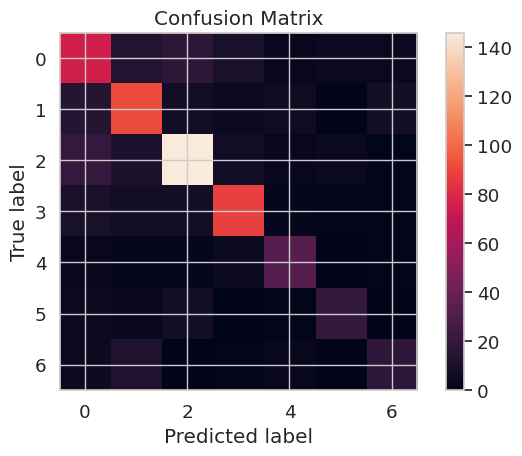

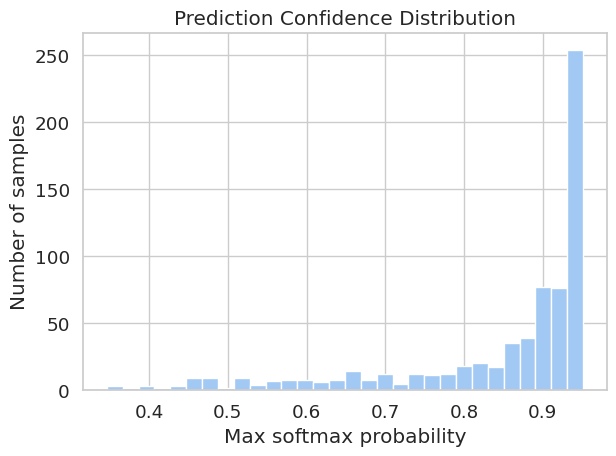

In [24]:
metrics = evaluate_on_test(
    trainer,
    ds["test"],
    label_names=emotion_labels,
    plot=True
)


#### _Dự đoán trên văn bản bất kỳ_

In [25]:
from typing import List, Optional, Union
import numpy as np
import torch
import pandas as pd
from scipy.special import softmax # Dùng softmax cho single-label

@torch.no_grad()
def predict_emotions(
    texts: Union[str, List[str]],
    model,
    tokenizer,
    emotion_labels: List[str],
    use_segmentation: bool = True,
    max_length: int = 256,
    batch_size: int = 32,
    return_scores: bool = True,
    top_k: Optional[int] = None,
):
    # 1. Chuẩn hóa input
    single = False
    if isinstance(texts, str):
        texts = [texts]
        single = True

    # 2. Tách từ (nếu cần)
    if use_segmentation:
        # Đảm bảo bạn đã có hàm vi_segment_one
        seg_texts = [vi_segment_one(t) for t in texts]
    else:
        seg_texts = list(texts)

    device = next(model.parameters()).device
    results = []

    # 3. Dự đoán theo batch
    for i in range(0, len(seg_texts), batch_size):
        batch_texts = seg_texts[i:i+batch_size]

        # Tokenize
        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        # Model forward
        outputs = model(**enc)
        logits = outputs.logits.detach().cpu().numpy() # [Batch_size, Num_labels]

        # --- THAY ĐỔI QUAN TRỌNG: SOFTMAX ---
        probs = softmax(logits, axis=1)

        # 4. Xử lý kết quả từng mẫu
        for j, prob in enumerate(probs):
            # Lấy nhãn tốt nhất (Argmax)
            pred_id = np.argmax(prob)
            pred_label = emotion_labels[pred_id]
            pred_score = prob[pred_id]

            # Top-k (nếu cần xem các phương án dự phòng)
            topk_list = None
            if top_k is not None:
                # Sắp xếp giảm dần
                top_indices = np.argsort(-prob)[:top_k]
                topk_list = [(emotion_labels[idx], float(prob[idx])) for idx in top_indices]

            # Bảng điểm chi tiết
            score_df = None
            if return_scores:
                score_df = pd.DataFrame({
                    "label": emotion_labels,
                    "score": prob.astype(float)
                }).sort_values("score", ascending=False).reset_index(drop=True)

            results.append({
                "text": texts[i + j],
                "pred_label": pred_label,  # Nhãn dự đoán duy nhất
                "confidence": float(pred_score), # Độ tự tin
                "top_k": topk_list,
                "scores": score_df
            })

    return results[0] if single else results

In [34]:
texts = [
    "Giờ vẫn ôm món nợ vài trăm nữa thím ạ, nhiều lúc nghĩ nhục nhã lắm nhưng vẫn cố làm để trả dần từng món một",
    "dcm thằng lồn A, nó láo quá ",
    "mới lụm đươc 50k rồi, dcmm sướng vãi loz",
    "Phim này chán ngắt, phí cả tiền vé 😡 ",
    "😡",
    "đùa vui đấy 😁",
    "đùa vui đấy 😡 ,",
    "trả tiền mau 😡",
    "trả tiền mau ",
    "cảm ơn nha",
    "t bị thằng bạn 36 lụm mất dép rồi",
    "hôm nay tao đi học bị nổ lốp xe mày ạ, xui vailz",
    "Cảm giác căng thẳng hôm nay không giống những ngày bình thường. Mình cứ nghĩ là mọi thứ sẽ ổn, rằng tình cảm giữa mình và V sẽ ngày càng tốt đẹp, nhưng sao hôm nay, khi mọi thứ vỡ vụn, mình lại cảm thấy như mình vừa bị tẩy chay, bị lợi dụng mà không hề hay biết.",
    "mày tự lập thì kệ thằng cụ nhà mày chứ, mỗi cây mỗi hoa, mỗi nhà mỗi cảnh, thằng thớt kêu than cuộc đời nó có đ gì sai. theo kinh nghiệm của tao, loại hay lên gân đạo lý là loại cóc nhái chó chết loser mạt hạng thôi"

  ]


preds = predict_emotions(texts, model, tokenizer, emotion_labels, top_k=3)

for p in preds:
    print(f"Text: {p['text']}")
    print(f"Dự đoán: {p['pred_label']} ({p['confidence']:.2%})")
    print(f"Top 3 khả năng: {p['top_k']}")
    print("-" * 30)

Text: Giờ vẫn ôm món nợ vài trăm nữa thím ạ, nhiều lúc nghĩ nhục nhã lắm nhưng vẫn cố làm để trả dần từng món một
Dự đoán: Sadness (92.42%)
Top 3 khả năng: [('Sadness', 0.9241691827774048), ('Fear', 0.027247706428170204), ('Enjoyment', 0.01447821594774723)]
------------------------------
Text: dcm thằng lồn A, nó láo quá 
Dự đoán: Anger (70.27%)
Top 3 khả năng: [('Anger', 0.7026715874671936), ('Disgust', 0.2362867146730423), ('Fear', 0.016150327399373055)]
------------------------------
Text: mới lụm đươc 50k rồi, dcmm sướng vãi loz
Dự đoán: Enjoyment (93.16%)
Top 3 khả năng: [('Enjoyment', 0.9316466450691223), ('Sadness', 0.014029367826879025), ('Surprise', 0.013697687536478043)]
------------------------------
Text: Phim này chán ngắt, phí cả tiền vé 😡 
Dự đoán: Disgust (89.45%)
Top 3 khả năng: [('Disgust', 0.8945258855819702), ('Sadness', 0.038093507289886475), ('Anger', 0.02014751546084881)]
------------------------------
Text: 😡
Dự đoán: Disgust (46.88%)
Top 3 khả năng: [('Disgust'

In [27]:
!pip install -q gradio

In [35]:
import gradio as gr

def gradio_wrapper(text):
    if not text.strip():
        return None

    # Gọi hàm dự đoán của bạn
    # Lưu ý: Biến 'model', 'tokenizer', 'emotion_labels' lấy từ context notebook
    result = predict_emotions(
        texts=text,
        model=model,
        tokenizer=tokenizer,
        emotion_labels=emotion_labels,
        use_segmentation=True,
        return_scores=True
    )

    # Chuyển đổi DataFrame 'scores' thành dictionary cho Gradio Label
    # result['scores'] là DataFrame có cột 'label' và 'score'
    df_scores = result['scores']
    output_dict = dict(zip(df_scores['label'], df_scores['score']))

    return output_dict

# --- 4. TẠO GIAO DIỆN ---
if 'model' in globals():
    demo = gr.Interface(
        fn=gradio_wrapper,
        inputs=gr.Textbox(lines=2, placeholder="Nhập văn bản tiếng Việt..."),
        outputs=gr.Label(num_top_classes=3, label="Kết quả dự đoán"),
        title="Dự đoán Cảm Xúc (Custom Function)",
        description="Demo sử dụng hàm predict_emotions tùy chỉnh.",
        examples=[
            ["Mình rất thích món quà này!"],
            ["Hôm nay buồn quá, chẳng muốn làm gì."],
            ["Thật là một sự thất vọng tràn trề."]
        ])
    demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://084ba6bbfeba66be17.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
